# PLAN NA TESTING METRYKI

- z macierzy korelacji wybrać lambdy ktore wyszly
- zrobić narzedzie które liczy score
- wygenerować graf - recznie(?) wygenerowac jakąś wizulizacje jego, jedna lepsza, jedna wyraźnie gorsza i popatrzeć czy metryka zwraca wynik który ma sens 
- w komponentach dac tez wersje komponentow bez zmian z artykulu
- porównać wyniki na 3 kategoriach grafu (BA ER SBM) i pomysleć czy przy wybieraniu lambd brać pod uwagę rodzaj tego grafu

In [1]:
import sys
from pathlib import Path

sys.path.insert(0,str(Path(r'C:\Users\ku51015\CHMURA\mystuff\Graph-Vizualisation-Rating-Metric-randoms\Graph-Vizualisation-Rating-Metric-randoms').resolve()))
# sys.path.insert(0,str(Path(r'C:\Users\Kinga\Desktop\MAGISTERKA\Graph-Vizualisation-Rating-Metric-3').resolve()))

from graph_generating_script import *
from graph_metric_script import *
import matplotlib.pyplot as plt
import igraph as ig
import numpy as np
import pickle
import seaborn as sns
from tqdm import tqdm

### connect all dataframes and generate coorelation for all

In [2]:


def calculate_lambdas_from_score_annotations(annotations_path, category, save_components_to_file=False):
    # annotations = pd.read_excel('randoms_ER_annotations_scores.xlsx')
    annotations = pd.read_excel(annotations_path)
    import os 
    posdf_dir = category + '/pos_dfs'
    graph_dir = category + '/graph_objects'


    calculated_components_df = pd.DataFrame(columns=['posdf_id', 'score', 
                                                    'node_distribution_unreversed','node_distribution', 'node_distribution_raw', 
                                                    'distance_to_borderlines_unreversed','distance_to_borderlines', 'distance_to_borderlines_raw', 
                                                    'edge_length_sum', 'edge_length_sum_raw', 
                                                    'edge_node_distance_contribution_unreversed','edge_node_distance_contribution','edge_node_distance_contribution_raw', 
                                                    'count_edge_crossings',  'count_edge_crossings_raw',
                                                    'communities_closeness', 'sum_of_angles', 'symmetry'])

    # Iterate through files in the posdf_dir
    skip_layouts = ['lgl']

    for posdf_file in tqdm(os.listdir(posdf_dir)):

        if posdf_file.split('_')[1].split('.')[0] not in skip_layouts:
            # reading data

            if posdf_file.endswith('.csv'):
                posdf = pd.read_csv(os.path.join(posdf_dir, posdf_file))
                # print(f'Loaded {posdf_file}')

            graph_id = posdf_file.split('_')[0]
            layout = posdf_file.split('.')[0]
            if int(graph_id) < 10:
                layout = layout[2:]
            else:
                layout = layout[3:]
            score = annotations[annotations['graph_id'] == int(graph_id)][layout].values[0]


            graph_file = 'graph_' + graph_id + '.pkl' 
            with open(os.path.join(graph_dir, graph_file), 'rb') as f:
                G = pickle.load(f)
                
            components_dict = {
                # what to leave  -> conclusions from correlation analysis and vibes
                # node_distribtuion, edge_to_brodelines_raw, edge_length_sum, edge_node_distance_contribution_raw, count_edge crossings_raw
                'posdf_id': posdf_file,
                'score': score,
                'node_distribution_unreversed': node_distribution_unreversed(posdf),
                'node_distribution': node_distribution(posdf),
                'node_distribution_raw': node_distribution_raw(posdf),
                'distance_to_borderlines_unreversed': distance_to_borderlines_unreversed(posdf),
                'distance_to_borderlines': distance_to_borderlines(posdf),
                'distance_to_borderlines_raw': distance_to_borderlines_raw(posdf),
                'edge_length_sum': edge_length_sum(G, posdf),
                'edge_length_sum_raw': edge_length_sum_raw(G, posdf),
                'edge_node_distance_contribution_unreversed': edge_node_distance_contribution_unreversed(G, posdf)[0],
                'edge_node_distance_contribution': edge_node_distance_contribution(G, posdf)[0],
                'edge_node_distance_contribution_raw': edge_node_distance_contribution_raw(G, posdf)[0],

                'count_edge_crossings': count_edge_crossings(G, posdf),
                'count_edge_crossings_raw': count_edge_crossings_raw(G, posdf),

                'communities_closeness' : intra_cluster_distance(G, posdf)['overall_sum'],
                'sum_of_angles' : sum_of_angles(G, posdf),
                'symmetry' : measure_graph_symmetry(G, posdf)
            }
            new_row_df = pd.DataFrame([components_dict])
            calculated_components_df = pd.concat([calculated_components_df, new_row_df], ignore_index=True)
            calculated_components_df_numeric = calculated_components_df.drop(columns=['posdf_id'])
    
    if save_components_to_file:
        calculated_components_df_numeric.to_csv(f'lambdas\calculated_components_{category}.csv', index=False)
    # Calculate the correlation matrix
    correlation_matrix = calculated_components_df_numeric.corr()

    # Extract the correlation of all values to 'score'
    score_correlation = correlation_matrix.loc[['score']]
    score_correlation['category'] = category
  

    return score_correlation

<>:71: SyntaxWarning: invalid escape sequence '\c'
<>:71: SyntaxWarning: invalid escape sequence '\c'
C:\Users\ku51015\AppData\Local\Temp\1\ipykernel_17832\631449166.py:71: SyntaxWarning: invalid escape sequence '\c'
  calculated_components_df_numeric.to_csv(f'lambdas\calculated_components_{category}.csv', index=False)


In [8]:
WS_corrs = calculate_lambdas_from_score_annotations('WS\WS_annotations_scores.xlsx','WS', True)
WS_corrs.to_csv('lambdas\WS_corrs.csv', index=False)
RGG_corrs = calculate_lambdas_from_score_annotations('RGG\RGG_annotations_scores.xlsx','RGG', True)
RGG_corrs.to_csv('lambdas\RGG_corrs.csv', index=False)
ER_corrs = calculate_lambdas_from_score_annotations('ER\ER_annotations_scores.xlsx','ER', True)
ER_corrs.to_csv('lambdas\ER_corrs.csv', index=False)
BA_corrs = calculate_lambdas_from_score_annotations('BA\BA_annotations_scores.xlsx','BA', True)
BA_corrs.to_csv('lambdas\BA_corrs.csv', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\W'
<>:2: SyntaxWarning: invalid escape sequence '\W'
<>:3: SyntaxWarning: invalid escape sequence '\R'
<>:4: SyntaxWarning: invalid escape sequence '\R'
<>:5: SyntaxWarning: invalid escape sequence '\E'
<>:6: SyntaxWarning: invalid escape sequence '\E'
<>:7: SyntaxWarning: invalid escape sequence '\B'
<>:8: SyntaxWarning: invalid escape sequence '\B'
<>:1: SyntaxWarning: invalid escape sequence '\W'
<>:2: SyntaxWarning: invalid escape sequence '\W'
<>:3: SyntaxWarning: invalid escape sequence '\R'
<>:4: SyntaxWarning: invalid escape sequence '\R'
<>:5: SyntaxWarning: invalid escape sequence '\E'
<>:6: SyntaxWarning: invalid escape sequence '\E'
<>:7: SyntaxWarning: invalid escape sequence '\B'
<>:8: SyntaxWarning: invalid escape sequence '\B'
C:\Users\ku51015\AppData\Local\Temp\1\ipykernel_18204\3983316489.py:1: SyntaxWarning: invalid escape sequence '\W'
  WS_corrs = calculate_lambdas_from_score_annotations('WS\WS_annotations_scores.xlsx'

C:\Users\ku51015\AppData\Local\Temp\1\ipykernel_18204\288013230.py:62: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  calculated_components_df = pd.concat([calculated_components_df, new_row_df], ignore_index=True)
  0%|          | 0/126 [00:00<?, ?it/s]C:\Users\ku51015\AppData\Local\Temp\1\ipykernel_18204\288013230.py:62: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  calculated_components_df = pd.concat([calculated_components_df, new_row_df], ignore_index=True)
  0%|          | 0/126 [00:00<?, ?i

In [10]:
# adding combined correlation
calculated_comp_WS = pd.read_csv('lambdas\calculated_components_WS.csv')
calculated_comp_BA = pd.read_csv('lambdas\calculated_components_BA.csv')
calculated_comp_ER = pd.read_csv('lambdas\calculated_components_ER.csv')
calculated_comp_RGG = pd.read_csv('lambdas\calculated_components_RGG.csv')
all_components = pd.concat([calculated_comp_WS, calculated_comp_BA, calculated_comp_ER, calculated_comp_RGG], ignore_index=True)

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:3: SyntaxWarning: invalid escape sequence '\c'
<>:4: SyntaxWarning: invalid escape sequence '\c'
<>:5: SyntaxWarning: invalid escape sequence '\c'
C:\Users\ku51015\AppData\Local\Temp\1\ipykernel_18204\178425426.py:2: SyntaxWarning: invalid escape sequence '\c'
  calculated_comp_WS = pd.read_csv('lambdas\calculated_components_WS.csv')
C:\Users\ku51015\AppData\Local\Temp\1\ipykernel_18204\178425426.py:3: SyntaxWarning: invalid escape sequence '\c'
  calculated_comp_BA = pd.read_csv('lambdas\calculated_components_BA.csv')
C:\Users\ku51015\AppData\Local\Temp\1\ipykernel_18204\178425426.py:4: SyntaxWarning: invalid escape sequence '\c'
  calculated_comp_ER = pd.read_csv('lambdas\calculated_components_ER.csv')
C:\Users\ku51015\AppData\Local\Te

In [15]:
all_components.to_csv('lambdas\calculated_components_all.csv', index=False)

<>:1: SyntaxWarning: invalid escape sequence '\c'
<>:1: SyntaxWarning: invalid escape sequence '\c'
C:\Users\ku51015\AppData\Local\Temp\1\ipykernel_18204\2341421549.py:1: SyntaxWarning: invalid escape sequence '\c'
  all_components.to_csv('lambdas\calculated_components_all.csv', index=False)


In [11]:
#@ calculate correlation for all
correlation_matrix = all_components.corr()

# Extract the correlation of all values to 'score'
All_corrs = correlation_matrix.loc[['score']]
All_corrs['category'] = 'All combined'
All_corrs.to_csv('lambdas\All_corrs.csv', index=False)
All_corrs

<>:7: SyntaxWarning: invalid escape sequence '\A'
<>:7: SyntaxWarning: invalid escape sequence '\A'
C:\Users\ku51015\AppData\Local\Temp\1\ipykernel_18204\1754139370.py:7: SyntaxWarning: invalid escape sequence '\A'
  All_corrs.to_csv('lambdas\All_corrs.csv', index=False)


,score,node_distribution,node_distribution_raw,distance_to_borderlines,distance_to_borderlines_raw,edge_length_sum,edge_length_sum_raw,edge_node_distance_contribution,edge_node_distance_contribution_raw,count_edge_crossings,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry,category
score,1.0,-0.361467,-0.311551,0.066717,0.077556,0.218111,0.189437,0.065453,0.061021,-0.07927,-0.168563,0.317675,0.056178,-0.389297,All combined


In [12]:
all_cats_corrs = pd.concat([WS_corrs, RGG_corrs, ER_corrs, BA_corrs, All_corrs], ignore_index=True)
all_cats_corrs

,score,node_distribution,node_distribution_raw,distance_to_borderlines,distance_to_borderlines_raw,edge_length_sum,edge_length_sum_raw,edge_node_distance_contribution,edge_node_distance_contribution_raw,count_edge_crossings,count_edge_crossings_raw,communities_closeness,sum_of_angles,symmetry,category
0,1.0,-0.426195,-0.343486,0.132005,0.139994,0.242659,0.198405,-0.281927,-0.337924,-0.154532,-0.221363,0.314869,0.044435,-0.500937,WS
1,1.0,-0.442839,-0.386970,0.130822,0.131458,0.090325,0.121934,0.130819,0.129815,-0.259799,-0.303147,0.319869,0.084007,-0.264608,RGG
2,1.0,-0.351749,-0.419731,0.132129,0.134250,0.359109,0.305512,0.011394,-0.188299,-0.116133,-0.151995,0.399499,0.091560,-0.471782,ER
3,1.0,-0.438908,-0.295487,0.493136,0.513931,0.188714,0.152569,-0.056300,-0.230325,-0.065893,-0.138188,0.287846,0.054358,-0.514301,BA
4,1.0,-0.361467,-0.311551,0.066717,0.077556,0.218111,0.189437,0.065453,0.061021,-0.079270,-0.168563,0.317675,0.056178,-0.389297,All combined


In [13]:
all_cats_corrs.set_index('category', inplace=True)


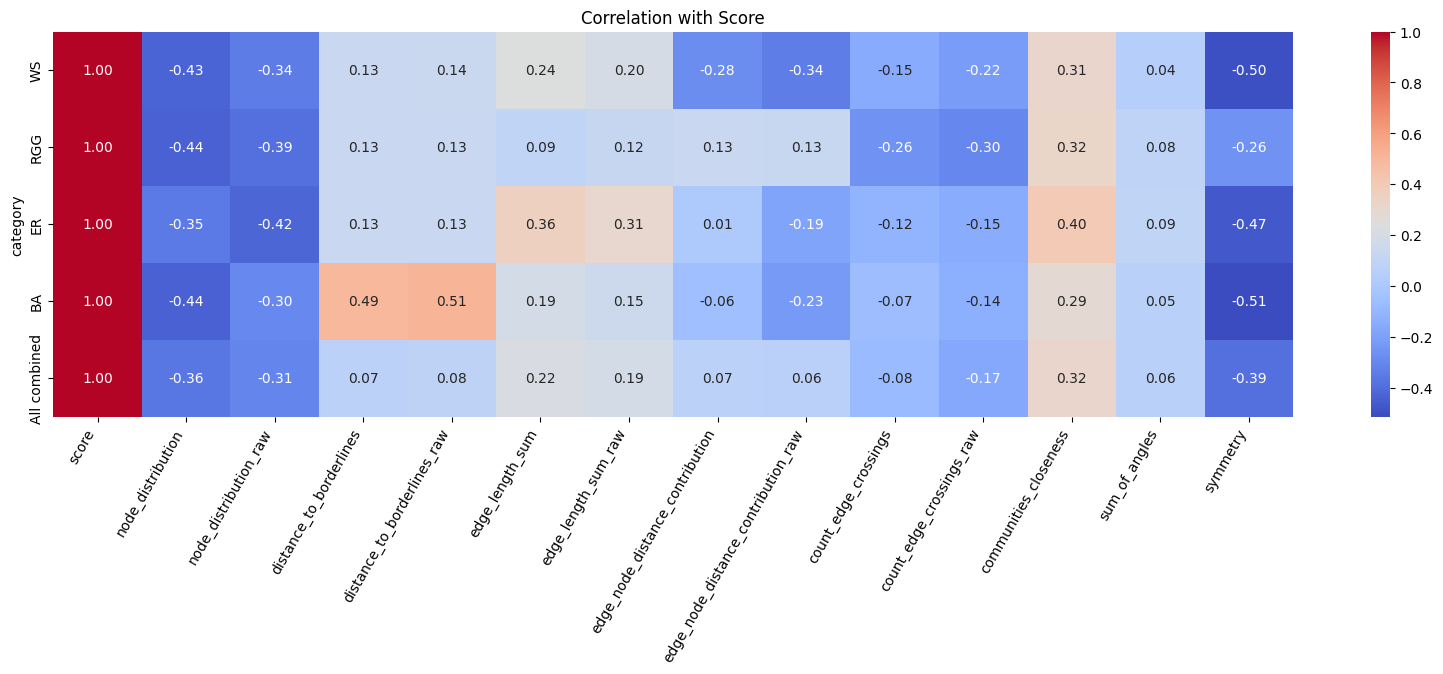

In [14]:
# Plot the heatmap
plt.figure(figsize=(20, 5))  # Adjust the figure size as needed
sns.heatmap(all_cats_corrs, annot=True, cmap='coolwarm', fmt='.2f', cbar=True)
plt.xticks(rotation=60, ha='right')
plt.title('Correlation with Score')
plt.show()